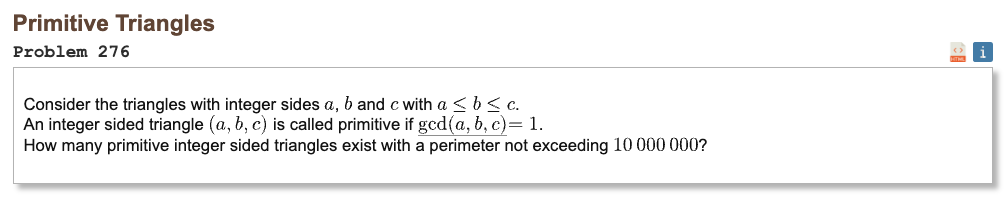

## Initial approach

* first count all integer triangles with exact perimeter n, not just primitive ones, because primitiveness can be peeled off later with Möbius inversion
* the number of all integer triangles with perimeter n has a closed form, namely the nearest integer to n²/48 for even n, and the nearest integer to (n+3)²/48 for odd n
* if g(n) is the number of primitive triangles with perimeter exactly n and a(n) is the total count, then a(n)=∑g(n/d), so g is recovered with Möbius inversion
* after summing over all perimeters up to N, the answer becomes ∑ μ(d) F(N//d), where F(m) is the cumulative count of all integer triangles up to perimeter m
* F(m) is a simple cubic quasipolynomial in m mod 12, so each term can be computed in O(1) instead of building a huge prefix table
* use array from the standard library to store Möbius values compactly, because a full Python int list up to 10^7 is unnecessarily heavy

In [1]:
%%time
from array import array

N = 10_000_000

def cumulative_all_triangles(n):
    q, r = divmod(n, 12)
    c = (0, 2, 3, 6, 8, 12, 15, 20, 24, 30, 35, 42)[r]
    d = (0, 0, 0, 1, 1, 2, 3, 5, 6, 9, 11, 15)[r]
    return 12 * q * q * q + (3 * r + 6) * q * q + c * q + d

mu = array('b', [0]) * (N + 1)
is_composite = bytearray(N + 1)
primes = array('I')
mu[1] = 1

for i in range(2, N + 1):
    if not is_composite[i]:
        primes.append(i)
        mu[i] = -1
    for p in primes:
        x = i * p
        if x > N:
            break
        is_composite[x] = 1
        if i % p == 0:
            mu[x] = 0
            break
        mu[x] = -mu[i]

result = cumulative_all_triangles(N)

for d in range(2, N + 1):
    md = mu[d]
    if md:
        result += md * cumulative_all_triangles(N // d)

print("Result:", result)

Result: 5777137137739632912
CPU times: user 3.88 s, sys: 18.6 ms, total: 3.9 s
Wall time: 3.93 s
